# Fixed CNN Training Pipeline

In [1]:
# Fix for corrupted / truncated images
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

In [2]:
# Install required libraries
!pip install -q torch torchvision torchaudio
!pip install -q timm
!pip install -q albumentations
!pip install -q scikit-learn
!pip install -q pillow
!pip install -q tqdm
# Install PyTorch with CUDA (adjust if needed)
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install -q timm albumentations scikit-learn pillow tqdm


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Imports
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import albumentations as A
from albumentations.pytorch import ToTensorV2
from PIL import Image
import timm

d:\PixelProof\ai_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# Config
IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 20
NUM_WORKERS = 2
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

In [5]:
import glob
import os

real_dir = r"D:\PixelProof\dataset\real"
fake_dir = r"D:\PixelProof\dataset\fake"

real_images = glob.glob(os.path.join(real_dir, "*.*"))
fake_images = glob.glob(os.path.join(fake_dir, "*.*"))

paths = real_images + fake_images
labels = [0]*len(real_images) + [1]*len(fake_images)

print(f"Real images: {len(real_images)}")
print(f"Fake images: {len(fake_images)}")
print(f"Total images: {len(paths)}")

from sklearn.model_selection import train_test_split

train_paths, val_paths, train_labels, val_labels = train_test_split(
    paths,
    labels,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

print(f"Train: {len(train_paths)}, Val: {len(val_paths)}")

Real images: 17775
Fake images: 18031
Total images: 35806
Train: 28644, Val: 7162


In [14]:
import timm
import torch.nn as nn

# Better model
model = timm.create_model('efficientnet_b0', pretrained=True, num_classes=2)
model = model.to(DEVICE)

# Loss
criterion = nn.CrossEntropyLoss()

# Optimizer with regularization (IMPORTANT)
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4   # 🔥 reduces overfitting
)

d:\PixelProof\ai_env\lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\tamha\.cache\huggingface\hub\models--timm--efficientnet_b0.ra_in1k. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


In [15]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

IMG_SIZE = 128

train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=15, p=0.5),
    A.RandomBrightnessContrast(p=0.4),
    A.GaussianBlur(p=0.2),
    A.ImageCompression(quality_lower=70, quality_upper=100, p=0.3),

    A.Normalize(mean=(0.485,0.456,0.406),
                std=(0.229,0.224,0.225)),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485,0.456,0.406),
                std=(0.229,0.224,0.225)),
    ToTensorV2()
])

In [7]:
from torch.utils.data import Dataset
import numpy as np
from PIL import Image
import torch

class ImageDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]

        try:
            img = Image.open(path).convert("RGB")

            # Resize early to avoid huge images issue
            img = img.resize((128, 128))
            img = np.array(img)

        except Exception as e:
            print(f"Skipping corrupted image: {path}")

            # fallback image
            img = np.zeros((128, 128, 3), dtype=np.uint8)

        if self.transform:
            img = self.transform(image=img)["image"]

        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return img, label

In [8]:
train_dataset = ImageDataset(train_paths, train_labels, train_transform)
val_dataset = ImageDataset(val_paths, val_labels, val_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=0   # keep 0 for now (Windows fix)
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0
)

In [9]:
# Model (lighter)
model = timm.create_model('resnet18', pretrained=True, num_classes=2)
model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [10]:
import time

start = time.time()

for i, (x, y) in enumerate(train_loader):
    print("First batch loaded:", i)
    break

print("Time taken:", time.time() - start)

First batch loaded: 0
Time taken: 0.20392537117004395


In [11]:
from torch.utils.data import DataLoader

BATCH_SIZE = 8

train_dataset = ImageDataset(train_paths, train_labels, train_transform)
val_dataset = ImageDataset(val_paths, val_labels, val_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0   # IMPORTANT for Windows
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

In [16]:
import torch

EPOCHS = 20

scaler = torch.amp.GradScaler('cuda') if DEVICE == 'cuda' else None

best_val_acc = 0
patience = 4
counter = 0

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=2, factor=0.5
)

for epoch in range(EPOCHS):
    
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()

        if DEVICE == 'cuda':
            with torch.amp.autocast('cuda'):
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

        else:
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

        total_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_acc = correct / total

    # -------- VALIDATION --------
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_acc = val_correct / val_total

    scheduler.step(val_acc)

    print(f"Train Loss: {total_loss/len(train_loader):.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss/len(val_loader):.4f}, Val Acc: {val_acc:.4f}")

    # Early stopping
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        counter = 0
        torch.save(model.state_dict(), "model_efficientnet_b0.pth")
        print("✅ Best model saved")

    else:
        counter += 1
        print(f"⚠️ No improvement ({counter}/{patience})")

    if counter >= patience:
        print("⛔ Early stopping triggered")
        break

print(f"\nBest Validation Accuracy: {best_val_acc:.4f}")


Epoch 1/20
Train Loss: 1.1226, Train Acc: 0.7299
Val Loss: 0.5307, Val Acc: 0.7980
✅ Best model saved

Epoch 2/20
Train Loss: 0.4119, Train Acc: 0.8221
Val Loss: 0.3171, Val Acc: 0.8704
✅ Best model saved

Epoch 3/20
Train Loss: 0.3377, Train Acc: 0.8546
Val Loss: 0.2896, Val Acc: 0.8873
✅ Best model saved

Epoch 4/20
Train Loss: 0.2935, Train Acc: 0.8771
Val Loss: 0.2562, Val Acc: 0.8954
✅ Best model saved

Epoch 5/20
Train Loss: 0.2400, Train Acc: 0.9004
Val Loss: 0.2751, Val Acc: 0.8910
⚠️ No improvement (1/4)

Epoch 6/20
Train Loss: 0.2075, Train Acc: 0.9166
Val Loss: 0.2324, Val Acc: 0.9094
✅ Best model saved

Epoch 7/20
Train Loss: 0.1753, Train Acc: 0.9311
Val Loss: 0.2370, Val Acc: 0.9088
⚠️ No improvement (1/4)

Epoch 8/20
Train Loss: 0.1501, Train Acc: 0.9408
Val Loss: 0.2497, Val Acc: 0.9113
✅ Best model saved

Epoch 9/20
Train Loss: 0.1337, Train Acc: 0.9478
Val Loss: 0.2560, Val Acc: 0.9085
⚠️ No improvement (1/4)

Epoch 10/20
Train Loss: 0.1204, Train Acc: 0.9547
Val Los

In [18]:
! pip install seaborn

  Using cached pandas-2.3.3-cp310-cp310-win_amd64.whl.metadata (19 kB)
  Using cached pytz-2026.1.post1-py2.py3-none-any.whl.metadata (22 kB)
Using cached pandas-2.3.3-cp310-cp310-win_amd64.whl (11.3 MB)
Using cached pytz-2026.1.post1-py2.py3-none-any.whl (510 kB)

   ---------------------------------------- 0/4 [pytz]
   ---------------------------------------- 0/4 [pytz]
   ---------- ----------------------------- 1/4 [tzdata]
   ---------- ----------------------------- 1/4 [tzdata]
   -------------------- ------------------- 2/4 [pandas]
   -------------------- ------------------- 2/4 [pandas]
   -------------------- ------------------- 2/4 [pandas]
   -------------------- ------------------- 2/4 [pandas]
   -------------------- ------------------- 2/4 [pandas]
   -------------------- ------------------- 2/4 [pandas]
   -------------------- ------------------- 2/4 [pandas]
   -------------------- ------------------- 2/4 [pandas]
   -------------------- ------------------- 2/4 [panda


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


C:\Users\tamha\AppData\Local\Temp\ipykernel_22212\1670893718.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("model_efficientnet_b0.pth

✅ Model loaded successfully


d:\PixelProof\ai_env\lib\site-packages\PIL\Image.py:1034: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
d:\PixelProof\ai_env\lib\site-packages\PIL\Image.py:3451: DecompressionBombWarning: Image size (121554000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


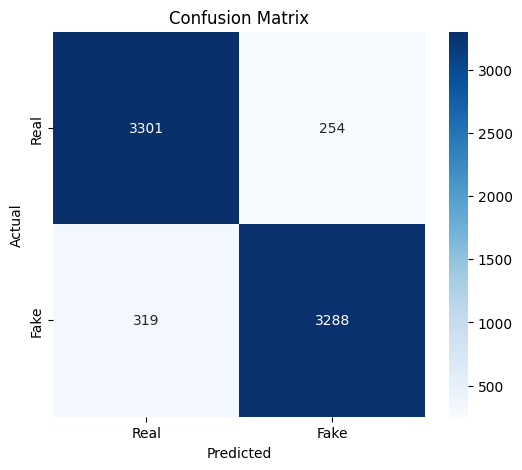


📊 Classification Report:

              precision    recall  f1-score   support

        Real       0.91      0.93      0.92      3555
        Fake       0.93      0.91      0.92      3607

    accuracy                           0.92      7162
   macro avg       0.92      0.92      0.92      7162
weighted avg       0.92      0.92      0.92      7162



In [19]:
import torch
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import timm

# ---- LOAD MODEL ----
model = timm.create_model('efficientnet_b0', pretrained=False, num_classes=2)
model.load_state_dict(torch.load("model_efficientnet_b0.pth", map_location=DEVICE))
model = model.to(DEVICE)
model.eval()

print("✅ Model loaded successfully")

# ---- EVALUATION ----
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(DEVICE)
        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# ---- CONFUSION MATRIX ----
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Real", "Fake"],
            yticklabels=["Real", "Fake"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# ---- CLASSIFICATION REPORT ----
print("\n📊 Classification Report:\n")
print(classification_report(all_labels, all_preds, target_names=["Real", "Fake"]))

In [ ]:
import torch
import numpy as np
from PIL import Image

def predict_image(image_path):
    model.eval()

    # Load image
    img = Image.open(image_path).convert("RGB")
    img = img.resize((128, 128))   # same as training

    img = np.array(img)

    # Apply same validation transform
    img = val_transform(image=img)["image"]

    # Add batch dimension
    img = img.unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        outputs = model(img)
        probs = torch.softmax(outputs, dim=1)
        pred = torch.argmax(probs, dim=1).item()

    classes = ["Real", "Fake"]

    print(f"Prediction: {classes[pred]}")
    print(f"Confidence: {probs[0][pred].item():.4f}")

    return classes[pred], probs[0][pred].item()

In [15]:
predict_image(r"C:\Users\tamha\Downloads\Gemini_Generated_Image_8s00ft8s00ft8s00.png")

Prediction: Fake
Confidence: 0.9897


('Fake', 0.9897243976593018)

In [16]:
! pip install fastapi uvicorn python-multipart

In [17]:
torch.save(model.state_dict(), "model.pth")